# Normalização do PTD

In [26]:
# Importar as bibliotecas necessárias
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd


In [35]:
# Carregar o ficheiro do PTD

path_ptd = r"C:\Users\carol\OneDrive\Desktop\Carolina\Milestone3\raw\postos-transformacao-distribuicao.shp"
ptd = gpd.read_file(path_ptd)

In [36]:
# Criar cópia e converter para numérico imediatamente
# A única coluna em análise neste notebook é 'Potencia_in', então focamos nela 
# pois queremos normalizar esta variável para integração futura com outros datasets (ex: consumo)
df = ptd.copy()
df['Potencia_in'] = pd.to_numeric(df['Potencia_in'], errors='coerce')

In [37]:
#Verificar a existência de valores nulos em 'Potencia_in' para decidir a estratégia de tratamento
print(f"Nulos em Potencia_in: {df['Potencia_in'].isnull().sum()}")

Nulos em Potencia_in: 0


Como não há valores nulos nesta coluna prossegue-se com a normalização dos dados e não é realizada nenhuma estratégia imputação de valores.

Skewness da Potência Instalada: 4.05
Kurtosis da Potência Instalada: 29.22


Text(0.5, 0, 'Potência Instalada (kVA)')

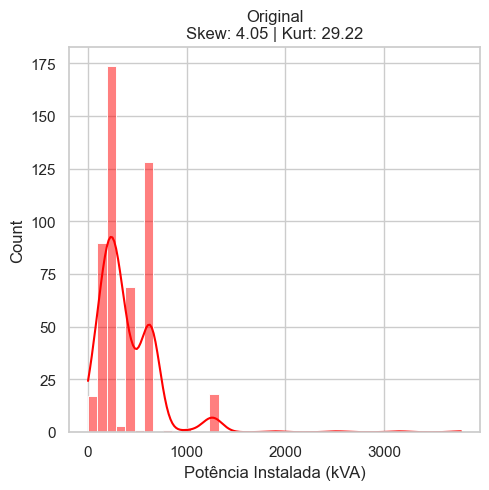

In [40]:
import seaborn as sns

#Assimetria
skew_potencia = df['Potencia_in'].skew()
kurtosis_potencia = df['Potencia_in'].kurt()

print(f"Skewness da Potência Instalada: {skew_potencia:.2f}")
print(f"Kurtosis da Potência Instalada: {kurtosis_potencia:.2f}")

plt.figure(figsize=(18, 5))

# Gráfico 1: Dados Originais
plt.subplot(1, 3, 1)
sns.histplot(df['Potencia_in'], kde=True, color='red')
plt.title(f'Original\nSkew: {skew_potencia:.2f} | Kurt: {kurtosis_potencia:.2f}')
plt.xlabel('Potência Instalada (kVA)')



A análise da assimetria revelou um cenário de forte assimetria positiva onde podemos constatar que existe um grande número de PTD de pequena e média potência de instalação mas que existe simultaneamente um pequeno número de PTD com grande potência instalada o que origina este desvio da cauda para a esquerda e origina então a asimetria de 4,05.  

Nova Skewness (pós-log): -2.13
Nova Kurtosis (pós-log): 12.61


Text(0.5, 0, 'Log(Potência + 1)')

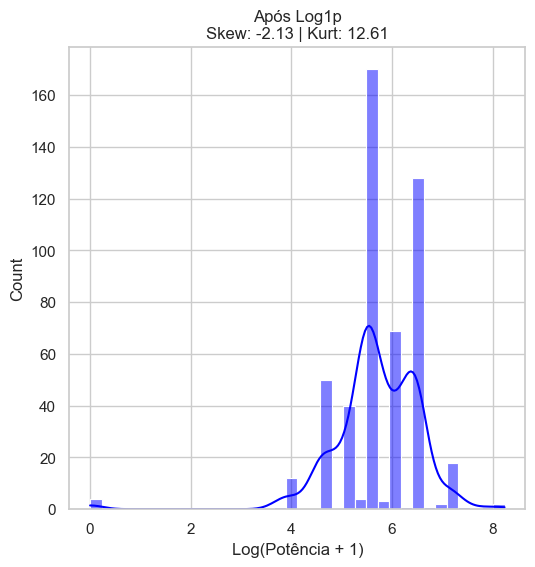

In [51]:

# 1. Aplicar Log1p para reduzir a Skewness e Kurtosis
# O log1p é log(x + 1), ideal para lidar com a escala de kVA
df['Potencia_in_log'] = np.log1p(df['Potencia_in'])

# 2. Calcular as novas métricas para verificar a melhoria
new_skew = df['Potencia_in_log'].skew()
new_kurt = df['Potencia_in_log'].kurt()

print(f"Nova Skewness (pós-log): {new_skew:.2f}")
print(f"Nova Kurtosis (pós-log): {new_kurt:.2f}")


# Visualização do gráfico
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 2)
sns.histplot(df['Potencia_in_log'], kde=True, color='blue')
plt.title(f'Após Log1p\nSkew: {new_skew:.2f} | Kurt: {new_kurt:.2f}')
plt.xlabel('Log(Potência + 1)')

Após a aplicação da transformação logarítmica ($log_{1p}$), observou-se uma correção substancial na morfologia da distribuição da variável 'Potência Instalada'. A curtose foi reduzida de 29.22 para 12.61, mitigando o impacto severo dos valores extremos. Embora a distribuição tenha transitado para uma assimetria negativa ($Skewness = -2.13$), este cenário revela-se estatisticamente preferível à original para a execução de modelos de autocorrelação espacial. Esta transformação assegura que a variância da capacidade instalada da rede é distribuída de forma mais equitativa, permitindo que o algoritmo de Moran I identifique padrões de vizinhança baseados na estrutura global da rede e não apenas na influência desproporcional dos postos de maior envergadura.